In [2]:
import os
import sys
import glob
from pathlib import Path
from astropy.io import fits
import numpy as np
from numpy import savetxt
import matplotlib
import matplotlib.pyplot as plt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from astropy import units as u
from astropy.coordinates import SkyCoord
#install dustmaps from https://github.com/gregreen/dustmaps
from dustmaps.sfd import SFDQuery
import pandas as pd
from astropy.table import Table
import gc
#matplotlib.use("Agg")
#plt.ioff()
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.cbook import get_sample_data
from astroquery.sdss import SDSS
import urllib.request
import warnings
from joblib import Parallel, delayed
#from ipyaladin import Aladin
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import WCS
import shutil

In [3]:
storage_dir = os.path.join(os.path.expanduser("~"),'Data_storageHII/')
os.makedirs(storage_dir, exist_ok=True)

In [4]:
fits_folder = storage_dir + '/HIIG_specDR7/'
spec_list = os.listdir(fits_folder)
spec_list.remove('DOWNspec_listDR7.txt')
spec_list = sorted(spec_list)
len(spec_list)

121

In [5]:
hdu = fits.open(fits_folder+spec_list[0])
plate,mjd,fiber = int(hdu[0].header['PLATEID']),int(hdu[0].header['MJD']),int(hdu[0].header['FIBERID'])
print(plate,mjd,fiber)
result = SDSS.query_specobj(plate=plate,mjd=mjd,fiberID=fiber)
result

267 51608 421


ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,int64
147.597162628828,0.708127177268213,1237648722290278498,756,301,5,212,0.09770181,267,51608,421,300731025703593984,26


In [6]:
catalog_file = os.path.join(storage_dir,"gal_info_dr7_v5_2.fit.gz")
catalog = catalog_file
catalog=Table.read(catalog)
w=((catalog['RA']!=catalog['DEC']) & (catalog['RA']>0) & ((catalog['DEC']>=-90) | (catalog['DEC']<=90)) & (catalog['Z']>=0) & ( catalog['Z'] != float('nan') ) & ( catalog['DEC'] != float('nan') ) & ( catalog['RA'] != float('nan') ))
reduced_cat=catalog[w]

In [7]:
spc_id,spc_ra,spc_dec,tb_id,tb_ra,tb_dec = [],[],[],[],[],[]

for i in range(len(spec_list)):
    hdu = fits.open(fits_folder+spec_list[i])
    plate,mjd,fiber = int(hdu[0].header['PLATEID']),int(hdu[0].header['MJD']),int(hdu[0].header['FIBERID'])
    #print(plate,mjd,fiber)
    hdu.close()

    tol = 0.01

    if i!=93 and i!=26:
        result = SDSS.query_specobj(plate=plate,mjd=mjd,fiberID=fiber)

        status = str(type(result))        

        if (status != "<class 'NoneType'>"):
            tabla5_art = pd.read_csv('Chavez2014_Tabla5.csv', sep=",", header=0) 
            f = (abs(tabla5_art['alpha(J2K)'] - result['ra'][0]) < tol) & (abs(tabla5_art['delta(J2K)'] - result['dec'][0]) < tol) & (abs(tabla5_art['z_hel'] - result['z'][0]) < tol)
            seleccion_a_index = tabla5_art[f]

            spc_id.append(spec_list[i])
            spc_ra.append(result['ra'][0])
            spc_dec.append(result['dec'][0])
            tb_id.append(seleccion_a_index['Index'].iloc[0])
            tb_ra.append(seleccion_a_index['alpha(J2K)'].iloc[0])
            tb_dec.append(seleccion_a_index['delta(J2K)'].iloc[0])



            if len(seleccion_a_index) == 1:
                #re_ra,re_dec,re_z = 
                re_ra,re_dec,re_z =  round(abs(seleccion_a_index['alpha(J2K)'].iloc[0] - result['ra'][0]),4),round(abs(seleccion_a_index['delta(J2K)'].iloc[0] - result['dec'][0]),4),round(abs(seleccion_a_index['z_hel'].iloc[0] - result['z'][0]),4)
                print(i,spec_list[i],' -> ',seleccion_a_index['Index'].iloc[0],' en Tabla 5   ->   ',re_ra,'    ',re_dec,'    ',re_z)
            else:
                print(i,' Parece haber ambiguedad con espectro ',spec_list[i],' N spectros posibles: ',len(seleccion_a_index))
        else:
            print('Espectro ',i,spec_list[i],' no esta en el Query de SDSS')

    else:
        ra = np.array(reduced_cat[(reduced_cat['PLATEID']==int(plate)) & (reduced_cat['FIBERID']==int(fiber)) & (reduced_cat['MJD']==int(mjd))]['RA'])[0]
        dec = np.array(reduced_cat[(reduced_cat['PLATEID']==int(plate)) & (reduced_cat['FIBERID']==int(fiber)) & (reduced_cat['MJD']==int(mjd))]['DEC'])[0]
        z = np.array(reduced_cat[(reduced_cat['PLATEID']==int(plate)) & (reduced_cat['FIBERID']==int(fiber)) & (reduced_cat['MJD']==int(mjd))]['Z'])[0] 
        tabla5_art = pd.read_csv('Chavez2014_Tabla5.csv', sep=",", header=0) 
        f = (abs(tabla5_art['alpha(J2K)'] - ra) < tol) & (abs(tabla5_art['delta(J2K)'] - dec) < tol) & (abs(tabla5_art['z_hel'] - z) < tol)
        seleccion_a_index = tabla5_art[f]

        spc_id.append(spec_list[i])
        spc_ra.append(ra)
        spc_dec.append(dec)
        tb_id.append(seleccion_a_index['Index'].iloc[0])
        tb_ra.append(seleccion_a_index['alpha(J2K)'].iloc[0])
        tb_dec.append(seleccion_a_index['delta(J2K)'].iloc[0])


        if len(seleccion_a_index) == 1:
            #re_ra,re_dec,re_z = 
            re_ra,re_dec,re_z =  round(abs(seleccion_a_index['alpha(J2K)'].iloc[0] - ra),4),round(abs(seleccion_a_index['delta(J2K)'].iloc[0] - dec),4),round(abs(seleccion_a_index['z_hel'].iloc[0] - z),4)
            print(i,spec_list[i],' -> ',seleccion_a_index['Index'].iloc[0],' en Tabla 5   ->   ',re_ra,'    ',re_dec,'    ',re_z)
        else:
            print(i,' Parece haber ambiguedad con espectro ',spec_list[i],' N spectros posibles: ',len(seleccion_a_index))

tupla_SPCTAB = [spc_id,spc_ra,spc_dec,tb_id,tb_ra,tb_dec]


0 spSpec-51608-0267-421.fit  ->  61  en Tabla 5   ->    0.0      0.0      0.0
1 spSpec-51690-0341-606.fit  ->  103  en Tabla 5   ->    0.0      0.0      0.0
2 spSpec-51793-0388-457.fit  ->  1  en Tabla 5   ->    0.0      0.0      0.0
3 spSpec-51810-0415-141.fit  ->  19  en Tabla 5   ->    0.0      0.0001      0.0
4 spSpec-51811-0381-370.fit  ->  126  en Tabla 5   ->    0.0001      0.0      0.0
5 spSpec-51816-0382-328.fit  ->  127  en Tabla 5   ->    0.0001      0.0      0.0
6 spSpec-51816-0410-220.fit  ->  16  en Tabla 5   ->    0.0      0.0      0.0
7 spSpec-51817-0418-302.fit  ->  5  en Tabla 5   ->    0.0      0.0      0.0001
8 spSpec-51820-0400-441.fit  ->  9  en Tabla 5   ->    0.0      0.0      0.0
9 spSpec-51820-0429-495.fit  ->  11  en Tabla 5   ->    0.0001      0.0      0.0001
10 spSpec-51821-0384-281.fit  ->  128  en Tabla 5   ->    0.0      0.0      0.0
11 spSpec-51877-0447-361.fit  ->  41  en Tabla 5   ->    0.0      0.0      0.0
12 spSpec-51882-0442-156.fit  ->  32  en Ta

In [8]:
if len(np.unique(tupla_SPCTAB[3])) == 121:
    print('Si hay match uno a uno')
else:
    print('No hay match uno a uno')


Si hay match uno a uno


In [253]:
selec = 120


aladin = Aladin(
    target=SkyCoord(tupla_SPCTAB[1][selec]*u.deg, tupla_SPCTAB[2][selec]*u.deg, unit="deg"),
    fov=Angle(0.01, "deg"),
    height =800,
    width = 500,
    reticle_size=20,
    coo_frame = "ICRSd",
    reticle_color="#08fd00",
    #overlay_survey = "SDSS9",
    #overlay_survey_opacity = 1,
    survey = "SDSS9"
)

aladin

Aladin(coo_frame='ICRSd', survey='SDSS9')

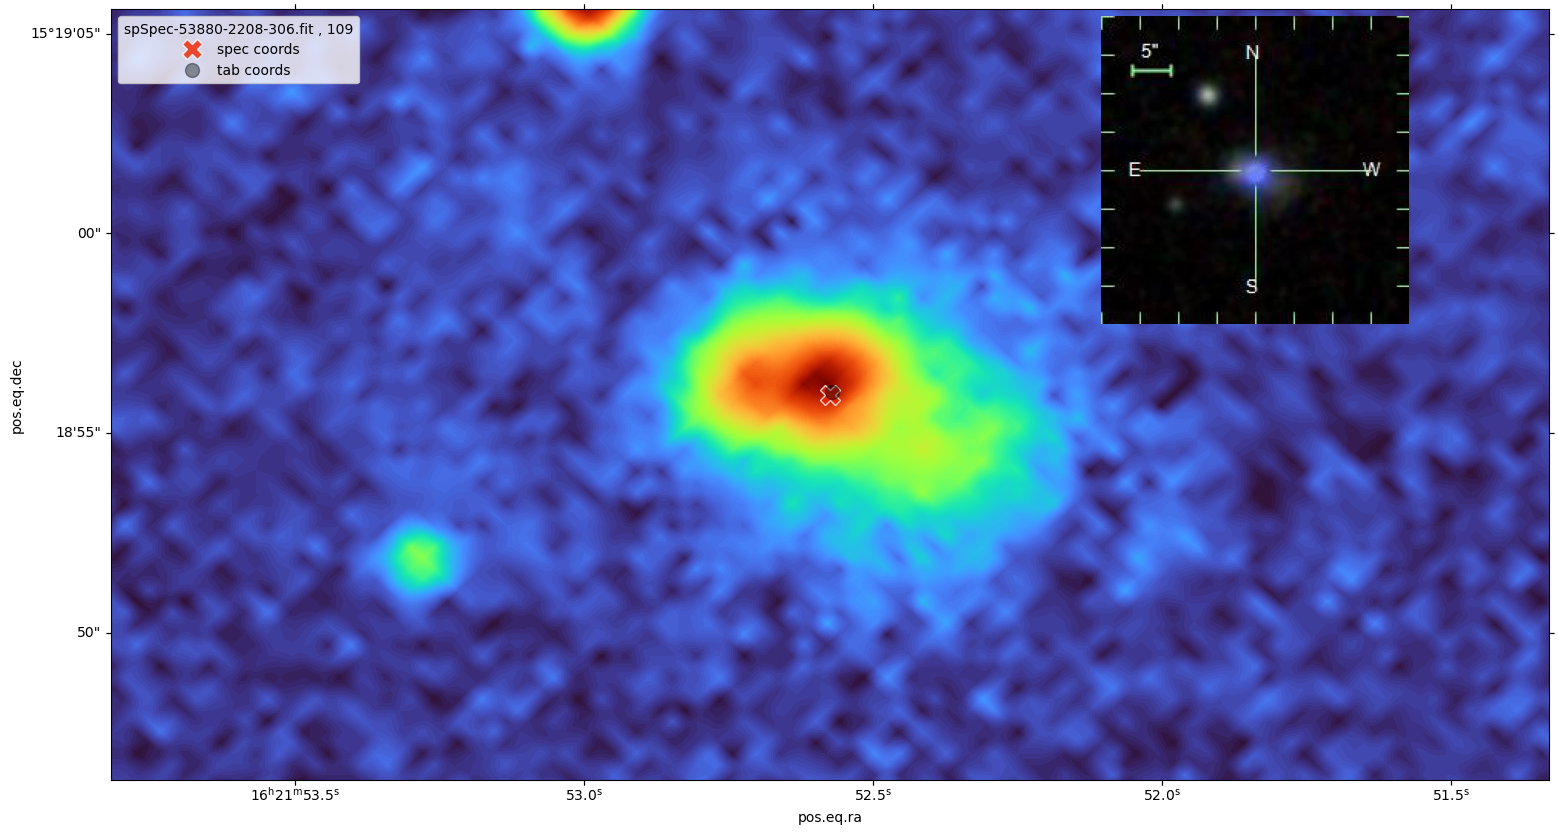

In [254]:
crossmatch_dir = os.path.join('','Tab5_spectraMatch/')
os.makedirs(crossmatch_dir, exist_ok=True)

HIIG_IMG_folder = storage_dir + '/HIIG_img/'
base_img = HIIG_IMG_folder + tupla_SPCTAB[0][selec].replace('.fit', '.fit.jpeg')

fits_o = aladin.get_view_as_fits()

wcs_d = WCS(fits_o[0].header)
r_data = fits_o[0].data[0, :,:]
g_data = fits_o[0].data[1, :,:]
b_data = fits_o[0].data[2, :,:]

rgb_composite = np.dstack((r_data, g_data, b_data))

s_x = []
s_y = []
coord_p = SkyCoord(tupla_SPCTAB[1][selec],tupla_SPCTAB[2][selec], unit=(u.deg, u.deg), frame='icrs')
x, y = coord_p.to_pixel(wcs_d, origin=0)
s_x.append(x)
s_y.append(y)

f_px = []
f_py = []
coord_p = SkyCoord(tupla_SPCTAB[4][selec],tupla_SPCTAB[5][selec], unit=(u.deg, u.deg), frame='icrs')
x, y = coord_p.to_pixel(wcs_d, origin=0)
f_px.append(x)
f_py.append(y)

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(1, 1, 1, projection=wcs_d, slices=('x', 'y', 3))
ax.imshow(r_data, cmap="turbo")
image_path = plt.imread(get_sample_data(base_img))
inset_ax = inset_axes(ax, width="40%", height="40%",loc='upper right')
inset_ax.imshow(image_path)
inset_ax.axis('off')

#specim_path = plt.imread(get_sample_data('/home/holman/Data_storageHII/HIIG_img/specimage_spSpec-53786-2356-172.fit.jpeg'))
#inset_ax = inset_axes(ax, width="40%", height="40%",loc='lower right')
#inset_ax.imshow(specim_path)
#inset_ax.axis('off')

ax.plot(s_x, s_y,
        markerfacecolor="#ee2400c6", marker='X', markersize=15, linewidth = 0, markeredgewidth = 1,markeredgecolor='white',
        label='spec coords',alpha= 0.8)
ax.plot(f_px, f_py, fillstyle='full',
        color='black', marker='o', markersize=10, linewidth = 0,
        label='tab coords',alpha= 0.4)

ax.legend(title = f'{tupla_SPCTAB[0][selec]} , {tupla_SPCTAB[3][selec]}',loc = 'upper left')
fig.savefig(f'{crossmatch_dir}/{tupla_SPCTAB[0][selec]}_{tupla_SPCTAB[3][selec]}.png')

In [9]:
for x in range(len(tupla_SPCTAB[0])):
    print(f'{tupla_SPCTAB[0][x]}	{tupla_SPCTAB[3][x]}')

spSpec-51608-0267-421.fit	61
spSpec-51690-0341-606.fit	103
spSpec-51793-0388-457.fit	1
spSpec-51810-0415-141.fit	19
spSpec-51811-0381-370.fit	126
spSpec-51816-0382-328.fit	127
spSpec-51816-0410-220.fit	16
spSpec-51817-0418-302.fit	5
spSpec-51820-0400-441.fit	9
spSpec-51820-0429-495.fit	11
spSpec-51821-0384-281.fit	128
spSpec-51877-0447-361.fit	41
spSpec-51882-0442-156.fit	32
spSpec-51908-0481-483.fit	63
spSpec-51909-0270-617.fit	72
spSpec-51909-0485-550.fit	53
spSpec-51910-0275-445.fit	82
spSpec-51910-0456-195.fit	15
spSpec-51910-0456-306.fit	14
spSpec-51910-0465-524.fit	20
spSpec-51913-0394-472.fit	6
spSpec-51914-0488-439.fit	68
spSpec-51924-0459-253.fit	18
spSpec-51929-0458-185.fit	17
spSpec-51929-0490-128.fit	93
spSpec-51955-0472-546.fit	49
spSpec-51959-0283-389.fit	96
spSpec-51981-0549-621.fit	36
spSpec-51991-0556-224.fit	55
spSpec-51997-0337-097.fit	100
spSpec-52000-0474-610.fit	52
spSpec-52138-0652-090.fit	2
spSpec-52140-0375-118.fit	121
spSpec-52140-0375-348.fit	120
spSpec-52145

In [10]:
print(f'{tupla_SPCTAB[1][55]},+{tupla_SPCTAB[2][55]}')

158.550948364493,+1.71362726467767


In [11]:
tab5_dir = os.path.join(storage_dir,'specTx_Tab5ID/')
os.makedirs(tab5_dir, exist_ok=True)

tex_folder = storage_dir + 'specTx_DR7/'
spec_list = os.listdir(tex_folder)
spec_list = sorted(spec_list)



In [12]:
df = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/Data_finders/Tab5_spectraMatch/sdss_tab5MATCH.csv')

for u in range(len(spec_list)):

    f = (df['name_sdss'] == spec_list[u].replace('.tex','.fit'))

    sorted_df = df[f]

    index_tab5 = str(sorted_df['name_table5'].iloc[0])

    if len(index_tab5) < 3:
        if len(index_tab5) < 2:
            index_tab5 = '00' + index_tab5
        else:
            index_tab5 = '0' + index_tab5

    new_name = f"{index_tab5}.Spc-{spec_list[u][-18:]}"

    print(new_name)

    shutil.copy2(tex_folder+spec_list[u], tab5_dir+new_name)
    

061.Spc-51608-0267-421.tex
103.Spc-51690-0341-606.tex
001.Spc-51793-0388-457.tex
019.Spc-51810-0415-141.tex
126.Spc-51811-0381-370.tex
127.Spc-51816-0382-328.tex
016.Spc-51816-0410-220.tex
005.Spc-51817-0418-302.tex
009.Spc-51820-0400-441.tex
011.Spc-51820-0429-495.tex
128.Spc-51821-0384-281.tex
041.Spc-51877-0447-361.tex
032.Spc-51882-0442-156.tex
063.Spc-51908-0481-483.tex
072.Spc-51909-0270-617.tex
053.Spc-51909-0485-550.tex
082.Spc-51910-0275-445.tex
015.Spc-51910-0456-195.tex
014.Spc-51910-0456-306.tex
020.Spc-51910-0465-524.tex
006.Spc-51913-0394-472.tex
068.Spc-51914-0488-439.tex
018.Spc-51924-0459-253.tex
017.Spc-51929-0458-185.tex
093.Spc-51929-0490-128.tex
049.Spc-51955-0472-546.tex
096.Spc-51959-0283-389.tex
036.Spc-51981-0549-621.tex
055.Spc-51991-0556-224.tex
100.Spc-51997-0337-097.tex
052.Spc-52000-0474-610.tex
002.Spc-52138-0652-090.tex
121.Spc-52140-0375-118.tex
120.Spc-52140-0375-348.tex
003.Spc-52145-0653-462.tex
115.Spc-52146-0639-143.tex
114.Spc-52146-0639-242.tex
0